In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from openTSNE import TSNE
import umap
from scipy.stats import mannwhitneyu

In [2]:
def stratify_age(x: np.ndarray, middle='median'):
    if middle=='median':
        middle=np.median(x)
    elif middle=='mean':
        middle=np.average(x)
    results=[]
    for i in x:
        if i<=middle: # less or equal to
            results.append("le%.2f"%middle)
        else: # greater than
            results.append("gt%.2f"%middle)
    return results, middle

In [3]:
if not os.path.exists("charts"):
    os.mkdir("charts")

# ASD-classification

In [4]:
target_col='diagnosis'
criteria='accuracy'

random_state=5
output_shape=40
num_heads=10
shrinking_speed=2
drop_out=0.1
middle_inflation=8
base_lr=1e-4

switch_data_source='GSE25507_example'
gene_list_name='cpn-15-047'

In [5]:
gene_list_dict={
    'cpn-15-047':
    [
        'HSF2',
        'RFX1',
        'NPM1',
        'MIER2',
        'MRPS31',
        'TC2N',
        'PKM',
        'C12orf29',
        'JADE2',
        'ACKR3',
        'ARHGAP15',
        'ATP6AP1',
        'TAPT1-AS1',
        'TMEM41B',
        'DCAF11'
    ],
}
gene_list=gene_list_dict[gene_list_name]

In [7]:
df=pd.read_csv(os.path.join("..","data","asd","joined-%s.tsv"%(switch_data_source)),sep='\t',header=0,index_col=0, low_memory=False)

In [8]:
print(np.sum(df.isna().values))

52


In [9]:
columns=list(df.columns)

In [10]:
used_genes=[]
for gene in gene_list:
    if type(gene)==type("") and gene in df.columns:
        used_genes.append(gene)
    elif type(gene)==type([]):
        for syn_name in gene:
            if syn_name in df.columns:
                used_genes.append(syn_name)
gene_list=used_genes
print(gene_list)
print("using a gene list containing %d genes!"%(len(gene_list)))

['HSF2', 'RFX1', 'NPM1', 'MIER2', 'MRPS31', 'TC2N', 'PKM', 'C12orf29', 'JADE2', 'ACKR3', 'ARHGAP15', 'ATP6AP1', 'TAPT1-AS1', 'TMEM41B', 'DCAF11']
using a gene list containing 15 genes!


In [11]:
print(columns[-8:])

['TAPT1-AS1', 'TMEM41B', 'DCAF11', 'type', 'maternal age', 'paternal age', 'age', 'diagnosis']


In [12]:
split_columns=[
    'paternal age'
]
df=df.loc[df['paternal age'].notna()&df[target_col].notna(),:]

In [13]:
df['paternal age'],middle =stratify_age(df['paternal age'].to_numpy(),middle='median')
print(middle)

31.0


In [14]:
df=df[gene_list+split_columns+[target_col]]

In [15]:
df[split_columns+[target_col]]

,paternal age,diagnosis
patient_ID,,
GSM627071,le31.00,0
GSM627072,gt31.00,0
GSM627073,le31.00,0
GSM627074,gt31.00,0
GSM627075,gt31.00,0
...,...,...
GSM627212,le31.00,1
GSM627213,le31.00,1
GSM627214,gt31.00,1


In [16]:
if np.sum(df.isna().values)>0:
    print("found NaN!")
    print("original shape: "+str(df.shape))
    df=df.dropna(axis=0)
print("shape: "+str(df.shape))

shape: (135, 17)


In [17]:
lengths=[]
for split in split_columns:
    for grp in df[split].unique():
        print("-----------------")
        print(split+" "+str(grp))
        print(df.loc[df[split]==grp,target_col].describe())
        lengths.append(len(df[split]==grp))

-----------------
paternal age le31.00
count    75.00000
mean      0.56000
std       0.49973
min       0.00000
25%       0.00000
50%       1.00000
75%       1.00000
max       1.00000
Name: diagnosis, dtype: float64
-----------------
paternal age gt31.00
count    60.000000
mean      0.600000
std       0.494032
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: diagnosis, dtype: float64


In [18]:
split='paternal age'
groups=list(df[split].unique())
target_col='diagnosis'

## Data description

In [19]:
os_counts = {
    'Control': np.array([np.sum(df[split]==groups[0])-np.sum(df.loc[df[split]==groups[0],target_col]), np.sum(df[split]==groups[1])-np.sum(df.loc[df[split]==groups[1],target_col])]),
    'ASD': np.array([np.sum(df.loc[df[split]==groups[0],target_col]), np.sum(df.loc[df[split]==groups[1],target_col])]),
}

(0.0, 80.0)

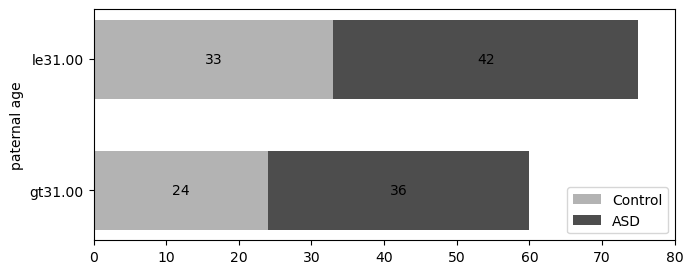

In [20]:
width = 0.6  # the width of the bars: can also be len(x) sequence
fig, ax = plt.subplots(figsize=(7.5,3))
bottom = np.zeros(len(groups))
colors={'Control':'0.7',"ASD":"0.3"}

for status, count in os_counts.items():
    p = ax.barh(groups[::-1], count[::-1], width, label=status, left=bottom[::-1], color=colors[status])
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend(loc='lower right')
ax.set_ylabel(split)
ax.set_xlim(left=0, right=80)

In [21]:
# plt.show()
fig.savefig(os.path.join("charts","ASD-A-groups.pdf"))

## Dimension reduction

In [22]:
tsne=TSNE(
    perplexity=len(gene_list)//5*3,
    metric="euclidean",
    n_jobs=8,
    random_state=random_state,
    verbose=False,
)
tsne_embedding=tsne.fit(df[gene_list])

In [23]:
tsne_df=pd.DataFrame(tsne_embedding,columns=['TSNE1','TSNE2'],index=df.index)

In [24]:
tsne_df=tsne_df.join(df[[target_col,split]].copy())

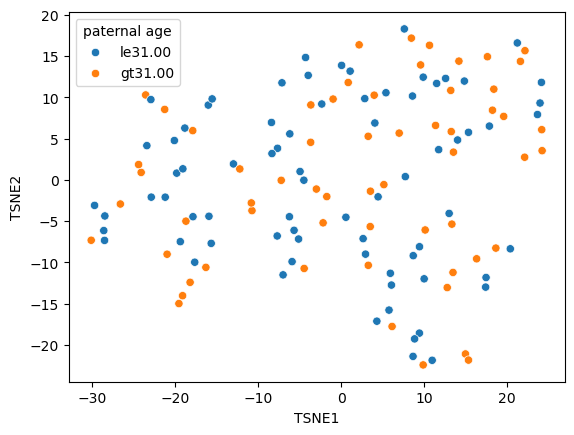

In [25]:
markers = {groups[0]: "X", groups[1]: "s"}
plot=sns.scatterplot(tsne_df,x='TSNE1',y='TSNE2', hue=split)
fig=plot.get_figure()
fig.savefig(os.path.join("charts","ASD-B-TNES-paternal_age.pdf"))

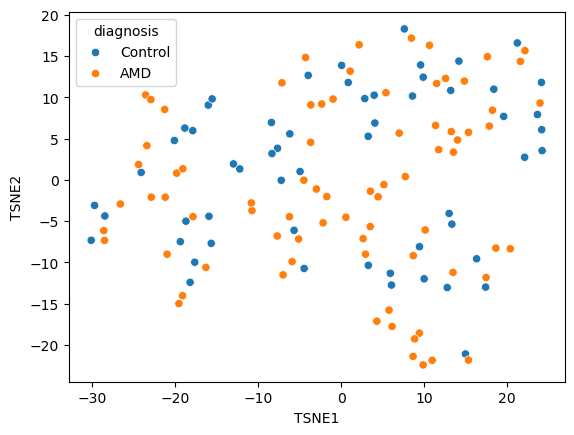

In [26]:
markers = {1: "X", 0: "s"}
plot=sns.scatterplot(tsne_df,x='TSNE1',y='TSNE2', hue=target_col)
handles, labels  =  plot.get_legend_handles_labels()
plot.legend(handles, ['Control', 'AMD'], title="diagnosis")
fig=plot.get_figure()
fig.savefig(os.path.join("charts","ASD-B-TNES-diagnosis.pdf"))

In [27]:
umap_embedding=umap.UMAP().fit_transform(df[gene_list])

In [28]:
umap_df=pd.DataFrame(umap_embedding,columns=['UMAP1','UMAP2'],index=df.index)

In [29]:
umap_df=umap_df.join(df[[target_col,split]].copy())

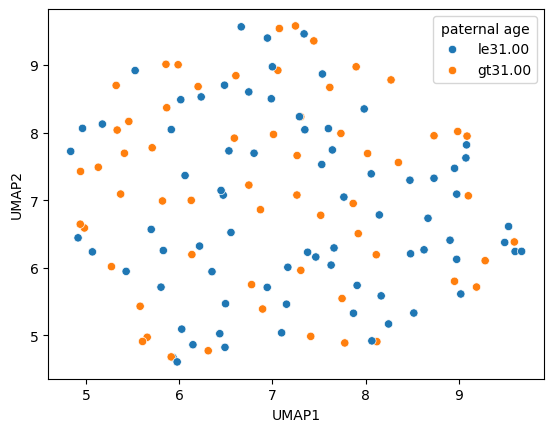

In [30]:
markers = {groups[0]: "X", groups[1]: "s"}
plot=sns.scatterplot(umap_df,x='UMAP1',y='UMAP2', hue=split)
fig=plot.get_figure()
fig.savefig(os.path.join("charts","ASD-B-UMAP-paternal_age.pdf"))

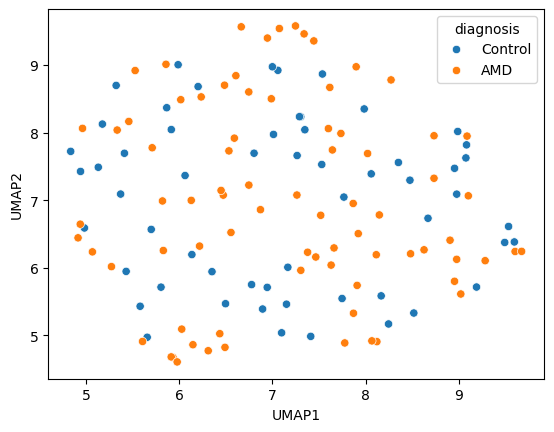

In [31]:
markers = {1: "X", 0: "s"}
plot=sns.scatterplot(umap_df,x='UMAP1',y='UMAP2', hue=target_col)
handles, labels  =  plot.get_legend_handles_labels()
plot.legend(handles, ['Control', 'AMD'], title="diagnosis")
fig=plot.get_figure()
fig.savefig(os.path.join("charts","ASD-B-UMAP-diagnosis.pdf"))

## delta VS p-value

In [32]:
grp_dict=dict()
for grp in groups:
    grp_dict[grp]={}
    for gene in gene_list:
        grp_dict[grp][gene]=df.loc[df[split]==grp,gene]

In [33]:
for i in range(len(gene_list)):
    gene=gene_list[i]
    a=grp_dict[groups[0]][gene].mean()-grp_dict[groups[1]][gene].mean()
    b=-math.log2(mannwhitneyu(grp_dict[groups[0]][gene],grp_dict[groups[1]][gene]).pvalue)
    if i==0:
        log_p_values=pd.DataFrame({'delta':a,'p-value':b},index=[gene])
    else:
        log_p_values=pd.concat([log_p_values,pd.DataFrame({'delta':a,'p-value':b},index=[gene])])

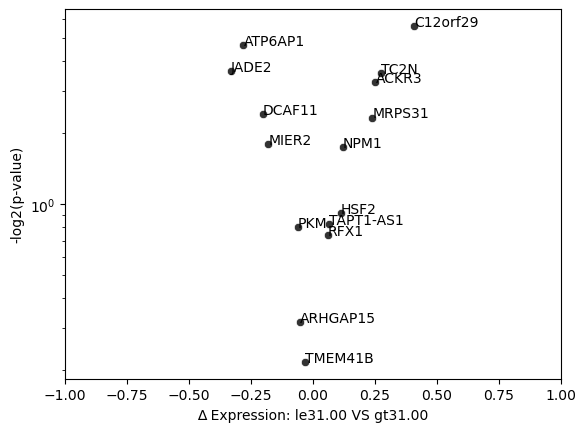

In [34]:
fig, scatter = plt.subplots()
scatter=sns.scatterplot(log_p_values,x='delta',y='p-value', color="0.2")
scatter.set_xlim(left=-1, right=1)
scatter.set_yscale('log')
for i, txt in enumerate(log_p_values.index):
    scatter.text(log_p_values.loc[txt,'delta'], log_p_values.loc[txt,'p-value'], txt)
scatter.set_xlabel('∆ Expression: '+groups[0]+" VS "+groups[1])
scatter.set_ylabel('-log2(p-value)')
fig.savefig(os.path.join("charts","ASD-C-delta.pdf"))

## performance

In [35]:
performance_results={
    'overall':{
        'EqualMark':0.9259,
        'one-shot':0.8519,
        'joint model':0.8889,
        'RF':0.5185,
        'DT':0.3704,
        'linear SVM':0.6296,
        'C-SVC':0.6667
    },
    groups[0]:{
        'EqualMark':0.9333,
        'one-shot':0.8667,
        'joint model':0.9231,
        'RF':0.4375,
        'DT':0.3125,
        'linear SVM':0.75,
        'C-SVC':0.5625
    },
    groups[1]:{
        'EqualMark':0.9167,
        'one-shot':0.8333,
        'joint model':0.8571,
        'RF':0.6364,
        'DT':0.4545,
        'linear SVM':0.4545,
        'C-SVC':0.8182
    },
}

In [36]:
performance_df=pd.DataFrame(performance_results)

In [37]:
performance_df=performance_df.transpose()

(0.0, 2.0)

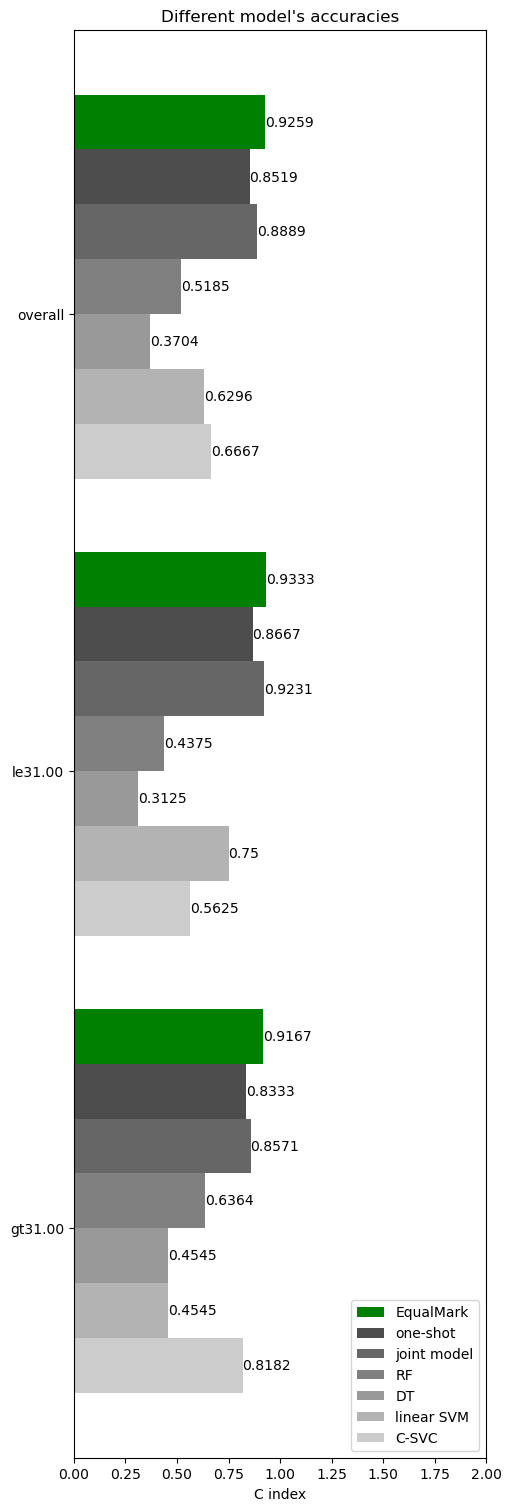

In [38]:
colors={
    'EqualMark':'g',
    'one-shot':"0.3",
    'joint model':"0.4",
    'RF':"0.5",
    "DT":"0.6",
    "linear SVM":"0.7",
    "C-SVC":"0.8"
    }

keys=list(performance_results.keys())
width=0.12
multiplier=len(performance_results['overall'])-1
x=np.arange(performance_df.shape[0])[::-1]

fig, ax = plt.subplots(layout='constrained',figsize=(5,15))

for attribute, measurement in performance_df.items():
    offset = width * multiplier
    rects = ax.barh(x + offset, measurement, width, label=attribute, color=colors[attribute])
    ax.bar_label(rects, padding=0, fontsize=10)
    multiplier -= 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('C index')
ax.set_title('Different model\'s accuracies')
ax.set_yticks(x + width*2.5, performance_df.index)
ax.legend(loc="lower right")
ax.set_xlim(0, 2)

In [39]:
# plt.show()
fig.savefig(os.path.join("charts","ASD-D-performances.pdf"))

## adjusted

In [40]:
adjusted_metrics={}
for mod in performance_results['overall'].keys():
    values=[performance_results[grp][mod] for grp in performance_results.keys() if grp!='overall']
    adjusted_metrics[mod]=performance_results['overall'][mod]/(1+max(values)-min(values))

In [41]:
adjusted_df=pd.DataFrame({"model":list(adjusted_metrics.keys()),"adjusted accuracy":list(adjusted_metrics.values())})

Text(0.5, 0, 'adjusted overall accuracies')

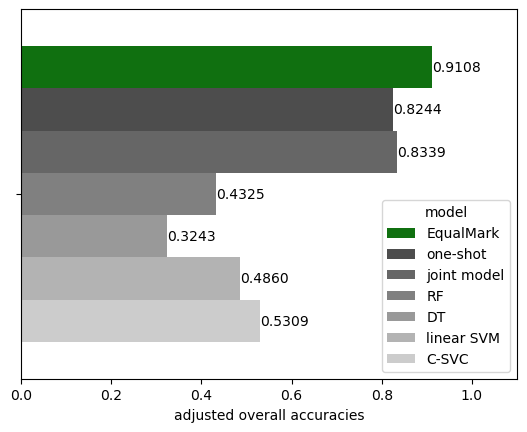

In [42]:
plot=sns.barplot(adjusted_df,x='adjusted accuracy',hue='model',orient='h', palette=colors)
for i in range(len(plot.containers)):
    plot.bar_label(plot.containers[i],fmt="%.4f",fontsize=10)
plot.set_xlim(0,1.1)
plot.set_xlabel("adjusted overall accuracies")

In [43]:
fig=plot.get_figure()
fig.savefig(os.path.join("charts","ASD-E-adjusted.pdf"))

## disparity

In [44]:
fairness_metrics={
    'relative performance diff.':{}
}
for mod in performance_results['overall'].keys():
    values=[performance_results[grp][mod] for grp in performance_results.keys() if grp!='overall']
    tmp=max(values)-min(values)
    fairness_metrics['relative performance diff.'][mod]=tmp/min(values)

In [45]:
fairness_df=pd.DataFrame(fairness_metrics).transpose()

(0.0, 0.8)

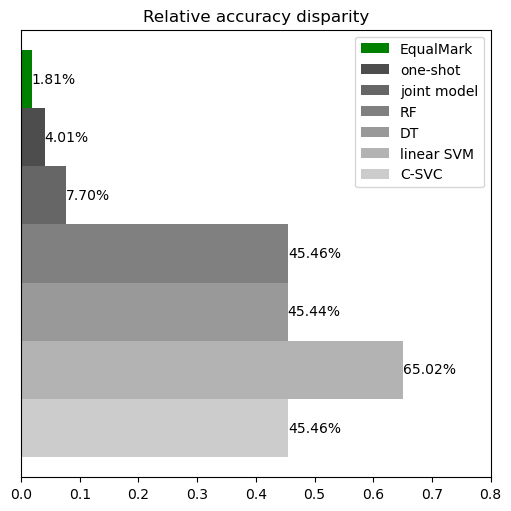

In [46]:
keys=list(fairness_df.keys())
width=0.15
multiplier=len(fairness_df)-1
x=np.arange(fairness_df.shape[0])[::-1]

fmt=lambda a: "%.2f"%(100*a)+"%"

fig, ax = plt.subplots(layout='constrained',figsize=(5,5))

for attribute, measurement in fairness_df.items():
    offset = width * multiplier
    rects = ax.barh(x + offset, measurement, width, label=attribute, color=colors[attribute])
    ax.bar_label(rects, fmt=fmt, padding=0, fontsize=10)
    multiplier -= 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.tick_params(left = False, labelleft = False) 
ax.set_title('Relative accuracy disparity')
ax.legend()
ax.set_xlim(0,0.8)

In [47]:
# plt.show()
fig.savefig(os.path.join("charts","ASD-F-fainess.pdf"))